# Part 1

## Setup

In [76]:
# Import core data manipulation libraries
import pandas as pd  # For working with tabular data (DataFrames)
import numpy as np  # For numerical operations and array computations

# Import PyPortfolioOpt components for portfolio optimization
from pypfopt import (
    EfficientFrontier,  # Main class for mean-variance optimization
    risk_models,  # Functions to estimate covariance matrices
    expected_returns,  # Functions to estimate expected returns
    objective_functions,  # Additional objectives like L2 regularization
)

# Import discrete allocation tools to convert weights to actual share counts
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# Import convex optimization library (used internally by PyPortfolioOpt)
import cvxpy as cp
import cvxpy.constraints

# Import visualization library (ggplot-style grammar of graphics for Python)
from plotnine import *
from plotnine import options as p9_options
from mizani.formatters import percent_format  # Format axis labels as percentages
from adjustText import adjust_text  # Automatically adjust text labels to avoid overlap

# Set default figure size for all plots
p9_options.figure_size = (8, 6)

# Configure pandas display options to show full outputs without truncation
pd.set_option("display.max_rows", None)  # Show all rows in output
pd.set_option("display.max_columns", None)  # Show all columns in output
pd.set_option("display.width", None)  # Auto-detect terminal width
pd.set_option("display.max_colwidth", None)  # Show full column content

## Read Data

In [77]:
returns_non = (
    pd.read_csv(
        "Data/pricedata.csv",  # CSV file with price data
    )
)

returns_non.head()

,Date,GOOGL,KR,T,F,CVX,MSFT,WMT,AMZN
0,12/31/2025,313.00,62.48,24.84,13.12,152.41,483.62,111.41,230.82
1,11/28/2025,320.18,67.28,26.02,13.28,151.13,492.01,110.51,233.22
2,10/31/2025,281.19,63.63,24.75,13.13,157.72,517.81,101.18,244.22
3,9/30/2025,243.10,67.41,28.24,11.96,155.29,517.95,103.06,219.57
4,8/29/2025,212.91,67.84,29.29,11.77,160.60,506.69,96.98,229.00


## Melt and Calculate Returns

In [78]:
returns = (
    pd.read_csv(
        "Data/pricedata.csv",  # CSV file with price data
    )
    # Convert mm/dd/yyyy date strings to proper datetime objects
    .assign(Date=lambda x: pd.to_datetime(x["Date"], format="%m/%d/%Y"))
    # Transform from wide format (one column per stock) to long format (one row per stock-date)
    .melt(id_vars="Date", var_name="symbol", value_name="adj_close")
    # Sort by stock symbol and then by date for proper time series ordering
    .sort_values(["symbol", "Date"])
    # Reset index after sorting
    .reset_index(drop=True)
    # Calculate percentage returns for each stock separately using groupby
    # pct_change() computes (price_t - price_{t-1}) / price_{t-1}
    .assign(ret=lambda df: df.groupby("symbol")["adj_close"].pct_change())
    # Remove the first observation for each stock (which has NaN return)
    .dropna()
)


returns.head()

,Date,symbol,adj_close,ret
1,2015-02-27,AMZN,19.01,0.072194
2,2015-03-31,AMZN,18.61,-0.021042
3,2015-04-30,AMZN,21.09,0.133262
4,2015-05-29,AMZN,21.46,0.017544
5,2015-06-30,AMZN,21.70,0.011184


## Annualization and SD

In [79]:

annualized_stats = (
    returns.groupby("symbol")["ret"]
    .agg(["mean", "std", "skew", lambda x: x.kurtosis()])
    .rename(columns={"<lambda_0>": "kurtosis"})
    .assign(
        ann_mean=lambda x: x["mean"] * 12,
        ann_vol=lambda x: x["std"] * np.sqrt(12),
    )
    .get(["ann_mean", "ann_vol", "skew", "kurtosis"])
    .round(3)
)
annualized_stats

,ann_mean,ann_vol,skew,kurtosis
symbol,,,,
AMZN,0.282,0.303,0.250,0.844
CVX,0.072,0.269,0.453,2.131
F,0.049,0.346,0.088,1.375
GOOGL,0.258,0.251,-0.097,0.031
KR,0.088,0.259,0.162,0.655
MSFT,0.252,0.216,0.318,0.076
T,-0.002,0.216,-0.194,0.897
WMT,0.144,0.188,-0.316,0.587


### Wide DF and EX Returns

In [80]:
annualisation_factor = 12

# Reshape data from long format to wide format (needed for PyPortfolioOpt functions)
# Each column represents one stock, each row represents one date
prices_wide = returns.get(["Date", "symbol", "adj_close"]).pivot(
    index="Date", columns="symbol", values="adj_close"
)

# Calculate mean historical returns for each asset (annualized)
mu = expected_returns.mean_historical_return(
    prices_wide, frequency=annualisation_factor, compounding=False  # Converts monthly to annual
)

# Display expected returns as a DataFrame (transposed for better readability)
pd.DataFrame({"expected_return": mu}).T

symbol,AMZN,CVX,F,GOOGL,KR,MSFT,T,WMT
expected_return,0.277464,0.068495,0.039599,0.255561,0.085399,0.246029,-0.006975,0.145967


###  Jarque–Bera Test

In [81]:
from scipy.stats import jarque_bera

jb_results = (
    returns.groupby("symbol")["ret"]
    .apply(lambda x: pd.Series(jarque_bera(x), index=["jb_stat", "p_value"]))
    .unstack()
    .assign(normal=lambda x: x["p_value"].apply(lambda p: "Fail to reject" if p > 0.05 else "Reject"))
    .round(4)
)
jb_results

,jb_stat,p_value,normal
symbol,,,
AMZN,4.5381,0.1034,Fail to reject
CVX,26.3066,0.0000,Reject
F,9.0730,0.0107,Reject
GOOGL,0.2028,0.9036,Fail to reject
KR,2.4305,0.2966,Fail to reject
MSFT,2.1562,0.3402,Fail to reject
T,4.4540,0.1079,Fail to reject
WMT,3.6068,0.1647,Fail to reject


# Part 2

## Cov Matrix

In [82]:
# Calculate the sample covariance matrix (annualized)
# This captures both individual asset volatilities and co-movements between assets
cov_matrix = risk_models.sample_cov(prices_wide, frequency=annualisation_factor)
# Display the covariance matrix
cov_matrix

symbol,AMZN,CVX,F,GOOGL,KR,MSFT,T,WMT
symbol,,,,,,,,
AMZN,0.092597,0.015716,0.030821,0.046183,0.013853,0.042917,0.003189,0.010410
CVX,0.015716,0.072786,0.046662,0.014084,0.009958,0.013579,0.023277,0.005584
F,0.030821,0.046662,0.119519,0.028517,0.009719,0.023478,0.017224,0.011896
GOOGL,0.046183,0.014084,0.028517,0.063315,0.011138,0.030818,0.005603,0.009185
KR,0.013853,0.009958,0.009719,0.011138,0.067616,0.009833,0.010939,0.020479
MSFT,0.042917,0.013579,0.023478,0.030818,0.009833,0.046454,0.007238,0.010077
T,0.003189,0.023277,0.017224,0.005603,0.010939,0.007238,0.046621,0.005176
WMT,0.010410,0.005584,0.011896,0.009185,0.020479,0.010077,0.005176,0.035620


## CAL

### Risk-Free Rate

In [83]:
# Take the average of the 1-month T-bill rate from January 2015 to December 2025
ff_factors = pd.read_csv("Data/F-F_Research_Data_Factors.csv")
ff_factors["Date"] = ff_factors["Date"].astype(int)
rf_2015_2025 = ff_factors[(ff_factors["Date"] >= 201501) & (ff_factors["Date"] <= 202512)]
avg_rf = rf_2015_2025["RF"].mean() / 100
print(f"Average monthly risk-free rate (Jan 2015 - Dec 2025): {avg_rf:.6f}")
print(f"Annualised risk-free rate: {avg_rf * 12:.6f}")

Average monthly risk-free rate (Jan 2015 - Dec 2025): 0.001584
Annualised risk-free rate: 0.019009


In [84]:
# Capital Allocation Line (CAL): E(r) = r_f + sharpe * sigma
rf_annual = avg_rf * 12
cal_slope = (max_sharpe_perf[0] - rf_annual) / max_sharpe_perf[1]
rf_point = pd.DataFrame({"volatility": [0], "expected_return": [rf_annual], "portfolio": ["Risk-Free"]})

## Min Variance Portfolio

In [85]:
# Minimum volatility portfolio
# Create a fresh EfficientFrontier object (each optimization needs its own instance)
ef_min_vol = EfficientFrontier(mu, cov_matrix, weight_bounds=(-1, 1))
# Add L2 regularization to prevent extreme weights
ef_min_vol.add_objective(objective_functions.L2_reg, gamma=0.01)
# Optimize for minimum volatility (ignores expected returns)
min_vol_weights = ef_min_vol.min_volatility()
# Clean up small weights for practical implementation
cleaned_min_vol = ef_min_vol.clean_weights()
# Calculate performance metrics
min_vol_perf = ef_min_vol.portfolio_performance(verbose=True)

print("\n" + "=" * 50)
print("MINIMUM VOLATILITY PORTFOLIO")
print("=" * 50)
# Convert weights to DataFrame and sort
min_vol_weights_df = (
    pd.Series(cleaned_min_vol, name="weight").sort_values(ascending=False).to_frame()
)
# Create metrics series
min_vol_metrics = pd.Series(
    min_vol_perf,
    index=["expected_return", "volatility", "sharpe_ratio"],
    name="min_vol_portfolio",
)
print("Portfolio weights:")
print(min_vol_weights_df)
print(f"\nPerformance metrics:")
print(min_vol_metrics)

Expected annual return: 12.7%
Annual volatility: 13.4%
Sharpe Ratio: 0.80

MINIMUM VOLATILITY PORTFOLIO
Portfolio weights:
        weight
WMT    0.29454
T      0.23437
MSFT   0.16127
GOOGL  0.10777
CVX    0.09706
KR     0.09459
AMZN   0.01365
F     -0.00325

Performance metrics:
expected_return    0.126961
volatility         0.133675
sharpe_ratio       0.800161
Name: min_vol_portfolio, dtype: float64


## Max Sharpe Ratio Portfolio (Optimal)

In [86]:
# Create efficient frontier object and compute portfolios
# Initialize with expected returns (mu) and covariance matrix
ef_sharpe = EfficientFrontier(mu, cov_matrix, weight_bounds=(-1, 1))
# Add L2 regularization to penalize extreme weights (gamma controls strength)
ef_sharpe.add_objective(objective_functions.L2_reg, gamma=0.01)

# Maximum Sharpe ratio portfolio (tangency portfolio)
# This solves: max (mu_p - r_f) / sigma_p where r_f = 0 by default
max_sharpe_weights = ef_sharpe.max_sharpe(risk_free_rate=rf_annual)
# Clean weights: remove tiny positions (below threshold) for practical implementation
cleaned_max_sharpe = ef_sharpe.clean_weights()
# Calculate portfolio performance metrics (expected return, volatility, Sharpe ratio)
max_sharpe_perf = ef_sharpe.portfolio_performance(verbose=True)

print("\n" + "=" * 50)
print("MAXIMUM SHARPE RATIO PORTFOLIO")
print("=" * 50)
# Convert weights dictionary to DataFrame and sort by weight size
max_sharpe_weights_df = (
    pd.Series(cleaned_max_sharpe, name="weight").sort_values(ascending=False).to_frame()
)
# Create metrics series for cleaner display
max_sharpe_metrics = pd.Series(
    max_sharpe_perf,
    index=["expected_return", "volatility", "sharpe_ratio"],
    name="max_sharpe_portfolio",
)
print("Portfolio weights:")
print(max_sharpe_weights_df)
print(f"\nPerformance metrics:")
print(max_sharpe_metrics)

Expected annual return: 29.4%
Annual volatility: 21.1%
Sharpe Ratio: 1.30

MAXIMUM SHARPE RATIO PORTFOLIO
Portfolio weights:
        weight
MSFT   0.47924
WMT    0.38793
GOOGL  0.34584
AMZN   0.12566
CVX    0.09711
KR    -0.03741
T     -0.19246
F     -0.20590

Performance metrics:
expected_return    0.294426
volatility         0.211137
sharpe_ratio       1.304446
Name: max_sharpe_portfolio, dtype: float64


/Users/zkhdf/Desktop/St.Andrews/Third Year/MN3101/Labs/lab2/lab-2-zachary-halnadufretay/.venv/lib/python3.10/site-packages/pypfopt/efficient_frontier/efficient_frontier.py:262: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
/Users/zkhdf/Desktop/St.Andrews/Third Year/MN3101/Labs/lab2/lab-2-zachary-halnadufretay/.venv/lib/python3.10/site-packages/pypfopt/efficient_frontier/efficient_frontier.py:444: UserWarning: The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.


## Plot

### Plot Setup

In [87]:
# Generate 8 efficient portfolios with evenly spaced target returns
target_returns = np.linspace(0.126961, 0.35, 8)

efficient_portfolios = []
for i, target in enumerate(target_returns):
    ef = EfficientFrontier(mu, cov_matrix, weight_bounds=(-1, 1))
    ef.add_objective(objective_functions.L2_reg, gamma=0.01)
    ef.efficient_return(target_return=float(target))
    cleaned = ef.clean_weights()
    perf = ef.portfolio_performance(verbose=False)
    efficient_portfolios.append({
        "portfolio": f"P{i + 1}",
        "target_return": round(target, 4),
        "expected_return": perf[0],
        "volatility": perf[1],
        "sharpe_ratio": perf[2],
        **cleaned,
    })

efficient_portfolios_df = pd.DataFrame(efficient_portfolios).set_index("portfolio")
efficient_portfolios_df.round(4)

,target_return,expected_return,volatility,sharpe_ratio,AMZN,CVX,F,GOOGL,KR,MSFT,T,WMT
portfolio,,,,,,,,,,,,
P1,0.1270,0.1270,0.1337,0.8002,0.0136,0.0971,-0.0032,0.1078,0.0946,0.1613,0.2344,0.2945
P2,0.1588,0.1588,0.1373,1.0110,0.0350,0.0971,-0.0418,0.1531,0.0695,0.2218,0.1532,0.3123
P3,0.1907,0.1907,0.1475,1.1570,0.0563,0.0971,-0.0804,0.1984,0.0444,0.2823,0.0720,0.3301
P4,0.2225,0.2225,0.1631,1.2419,0.0776,0.0971,-0.1189,0.2437,0.0192,0.3428,-0.0093,0.3478
P5,0.2544,0.2544,0.1827,1.2834,0.0989,0.0971,-0.1575,0.2890,-0.0059,0.4033,-0.0905,0.3656
P6,0.2863,0.2863,0.2051,1.2986,0.1202,0.0971,-0.1960,0.3342,-0.0310,0.4638,-0.1717,0.3834
P7,0.3181,0.3181,0.2295,1.2992,0.1415,0.0971,-0.2346,0.3796,-0.0561,0.5243,-0.2529,0.4012
P8,0.3500,0.3500,0.2553,1.2924,0.1628,0.0971,-0.2732,0.4248,-0.0812,0.5848,-0.3341,0.4189


In [88]:
# Enhanced efficient frontier visualization with Tidy Finance techniques
ridge_gamma = 0.01  # Regularization parameter for all optimizations
# Create grid of target returns to trace out the frontier
frontier_grid = np.linspace(mu.min(), 0.35, 50)


def compute_frontier_points(target_returns, mu_vec, cov, gamma, weight_bounds=(-1, 1)):
    """
    Sample efficient frontier points for plotting.

    Args:
        target_returns: Array of target return values to optimize for
        mu_vec: Expected returns vector
        cov: Covariance matrix
        gamma: L2 regularization parameter
        weight_bounds: Tuple of (min_weight, max_weight) for each asset
                      (-1, 1) allows shorting; (0, 1) is long-only

    Returns:
        DataFrame with expected_return, volatility, sharpe_ratio for each point
    """
    rows = []
    for target in target_returns:
        # Create fresh optimizer for each target
        ef = EfficientFrontier(mu_vec, cov, weight_bounds=weight_bounds)
        ef.add_objective(objective_functions.L2_reg, gamma=gamma)
        try:
            # Try to find portfolio that achieves target return with minimum risk
            ef.efficient_return(target_return=float(target))
            # Get performance metrics (return, volatility, Sharpe)
            perf = ef.portfolio_performance(verbose=False)
        except (ValueError, OverflowError):
            # Skip this target if optimization fails (infeasible or numerical issues)
            continue
        rows.append(
            {
                "expected_return": perf[0],
                "volatility": perf[1],
                "sharpe_ratio": perf[2],
            }
        )
    return (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["volatility"])  # Remove duplicate points
        .sort_values("volatility")  # Sort by increasing risk
        .reset_index(drop=True)
    )


frontier = compute_frontier_points(
    frontier_grid, mu, cov_matrix, ridge_gamma, (-1, 1)
)


# Individual asset positions (for reference on plot)
asset_positions = pd.DataFrame(
    {
        "symbol": mu.index,
        "expected_return": mu,
        "volatility": np.sqrt(np.diag(cov_matrix)),  # Square root of variance
    }
).reset_index(drop=True)

# Key portfolios for annotation on plot
key_portfolios = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "portfolio": "Min Vol (G)",
                    "expected_return": min_vol_perf[0],
                    "volatility": min_vol_perf[1],
                },
                {
                    "portfolio": "Max Sharpe (P)",
                    "expected_return": max_sharpe_perf[0],
                    "volatility": max_sharpe_perf[1],
                },
            ]
        ),
        efficient_portfolios_df[["expected_return", "volatility"]]
        .reset_index()
        .rename(columns={"portfolio": "portfolio"}),
    ],
    ignore_index=True,
)

## Plot Construction

0 [ 0.33906025 -0.52754656]
2 [ 0.77869994 -0.16893295]


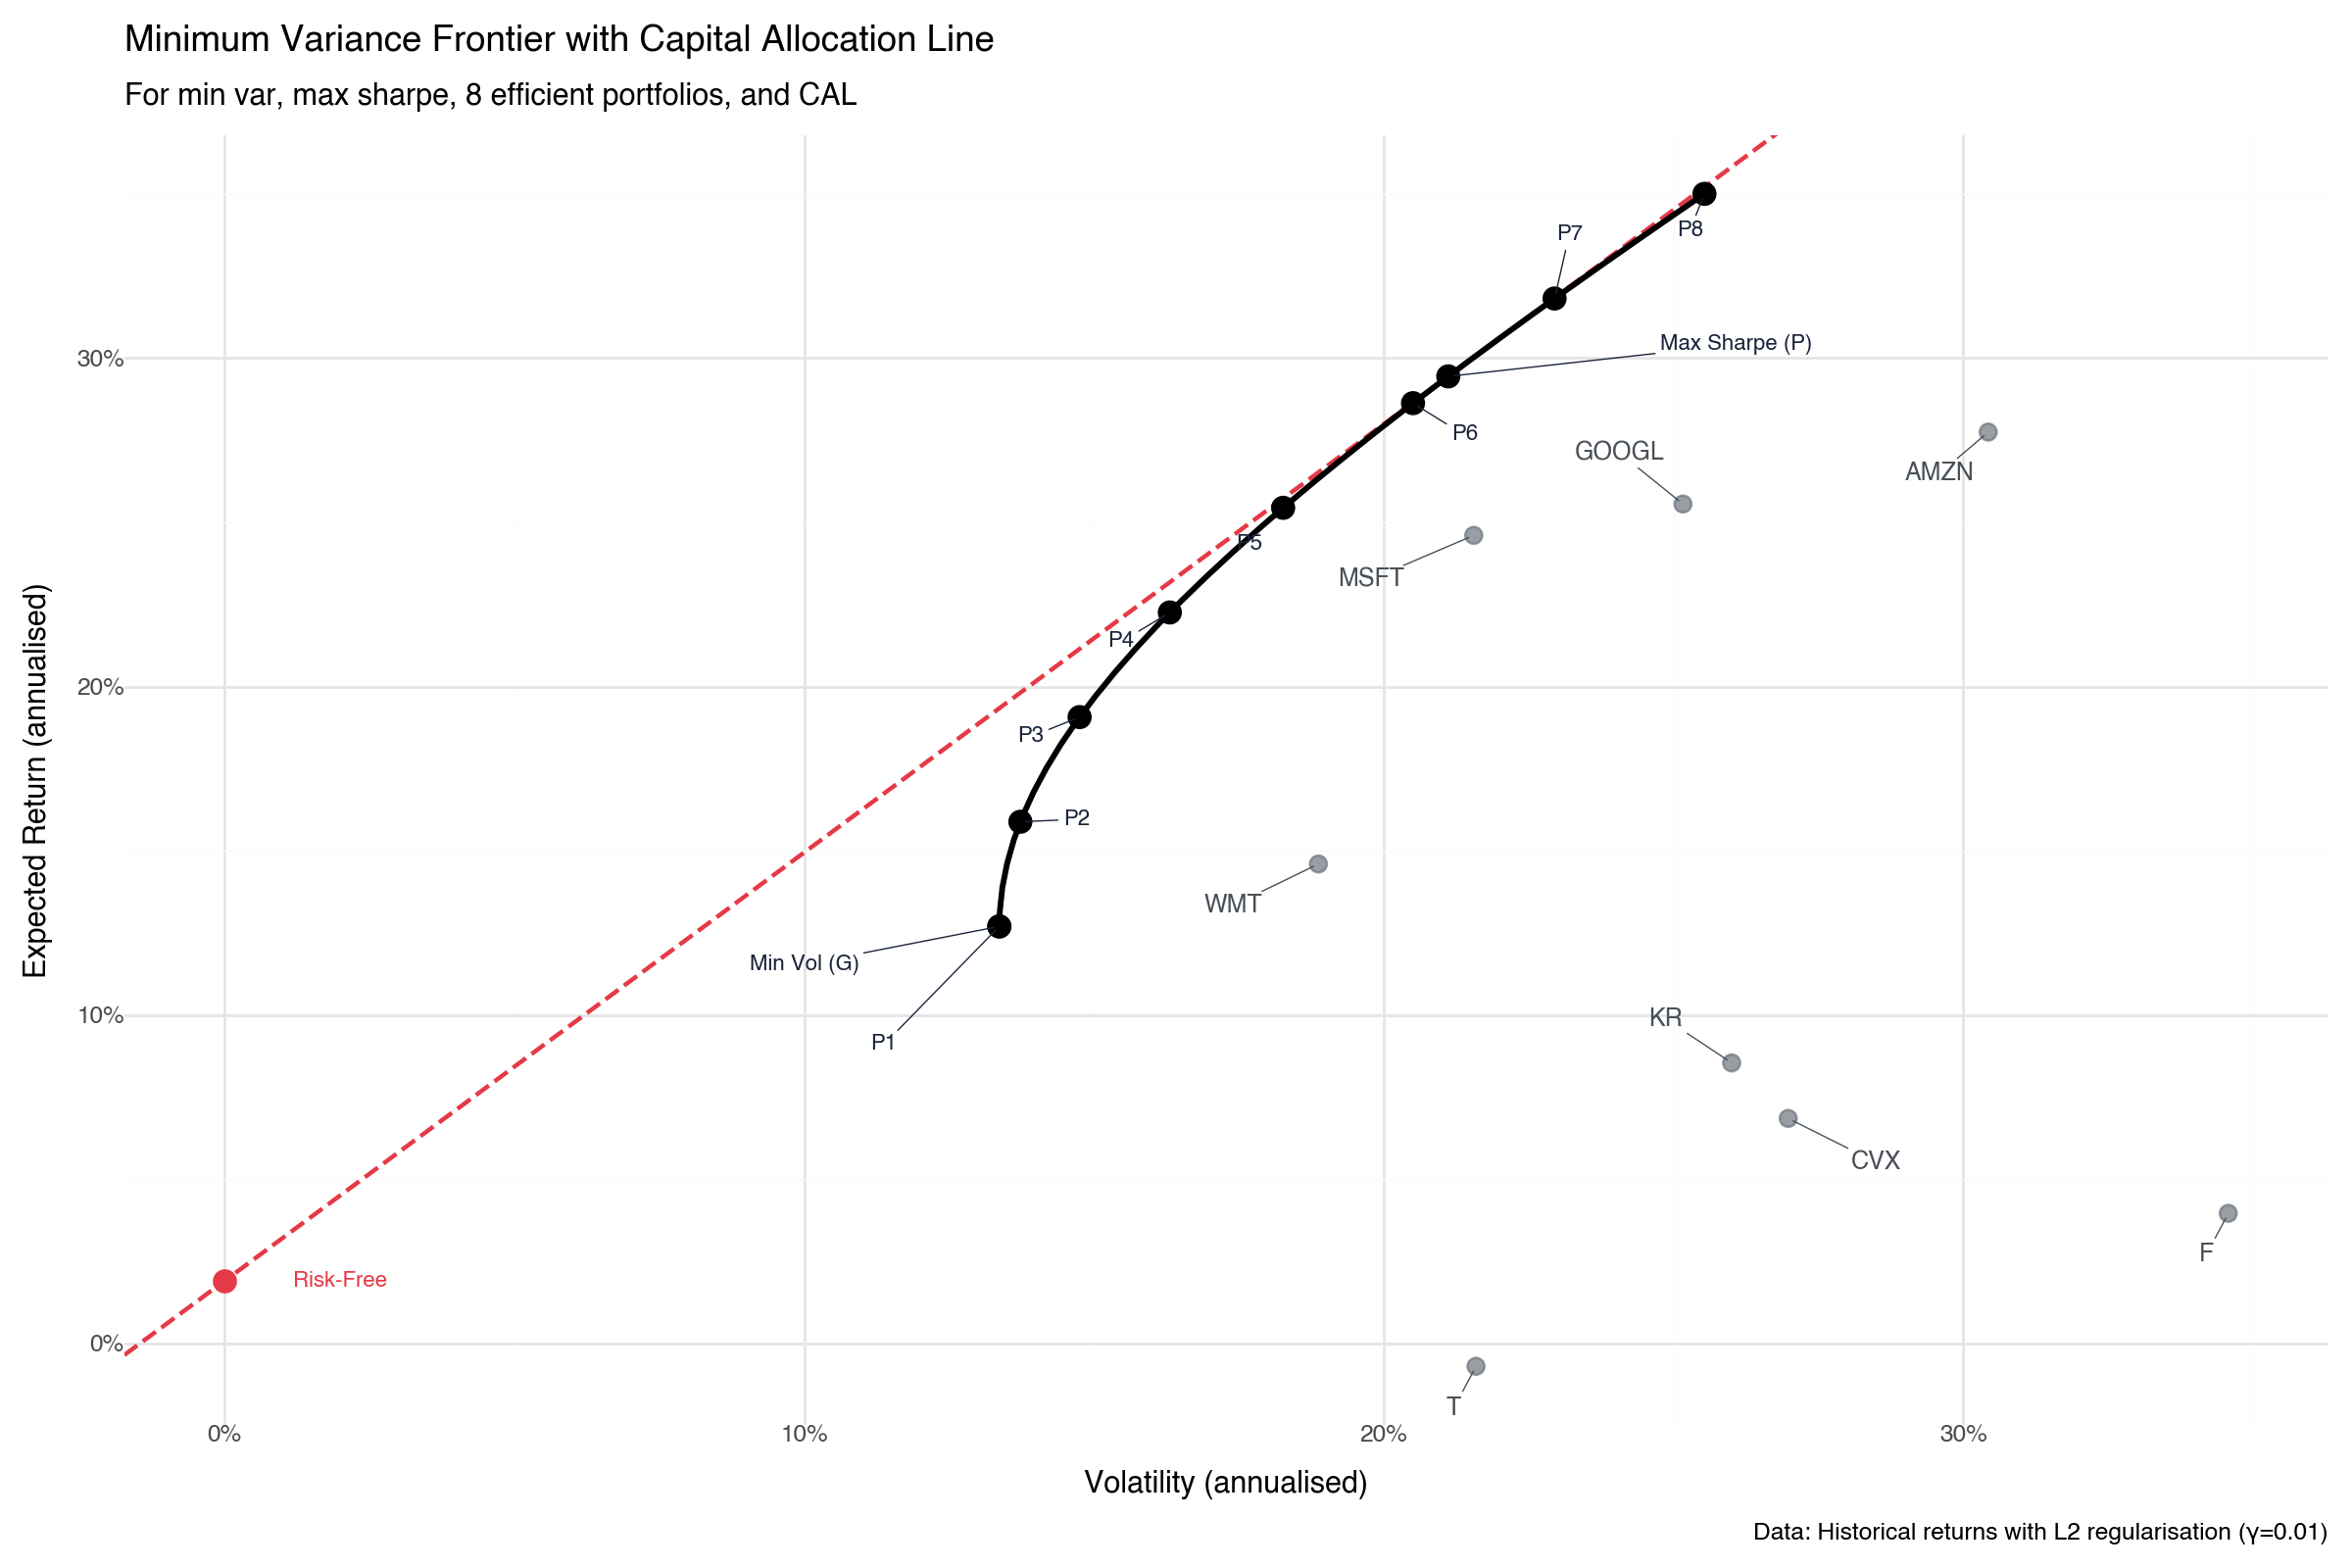

In [89]:


# Enhanced plot with Tidy Finance styling
enhanced_plot = (
    # Initialize empty plot (we'll add multiple layers)
    ggplot()
    # Capital Allocation Line from risk-free rate through tangency portfolio
    + geom_abline(
        intercept=rf_annual,
        slope=cal_slope,
        linetype="dashed",
        color="#e63946",
        size=0.9,
    )
    # Risk-free rate point on the y-axis
    + geom_point(
        rf_point,
        aes(x="volatility", y="expected_return"),
        color="#e63946",
        size=4,
    )
    + geom_text(
        rf_point,
        aes(x="volatility", y="expected_return", label="portfolio"),
        nudge_x=0.02,
        size=8,
        color="#e63946",
    )
    # Add efficient frontier lines (one for each constraint type)
    + geom_line(
        frontier,
        aes(x="volatility", y="expected_return"),
        size=1.2,
    )
    # Add individual asset positions as reference points
    + geom_point(
        asset_positions,
        aes(x="volatility", y="expected_return"),
        color="#6c757d",  # Neutral gray color
        size=3,
        alpha=0.7,  # Semi-transparent
    )
    # Add labels for individual assets (with automatic positioning to avoid overlap)
    + geom_text(
        asset_positions,
        aes(x="volatility", y="expected_return", label="symbol"),
        adjust_text={"arrowprops": {"arrowstyle": "-"}},
        size=9,
        color="#495057",
    )
    # Add key portfolio positions (MVP, Max Sharpe, etc.)
    + geom_point(
        key_portfolios,
        aes(
            x="volatility",
            y="expected_return",
        ),
        size=4,
    )
    # Add labels for key portfolios
    + geom_text(
        key_portfolios,
        aes(x="volatility", y="expected_return", label="portfolio"),
        adjust_text={"arrowprops": {"arrowstyle": "-"}},
        size=8,
        color="#1b263b",
    )
    # Format x-axis as percentages
    + scale_x_continuous(labels=percent_format())
    # Format y-axis as percentages
    + scale_y_continuous(labels=percent_format())
    # Add comprehensive labels
    + labs(
        title="Minimum Variance Frontier with Capital Allocation Line",
        subtitle="For min var, max sharpe, 8 efficient portfolios, and CAL",
        x="Volatility (annualised)",
        y="Expected Return (annualised)",
        caption="Data: Historical returns with L2 regularisation (γ=0.01)",
    )
    # Use minimal theme for clean look
    + theme_minimal()
    # Set custom figure size
    + theme(figure_size=(12, 8))
)

# Display the plot
enhanced_plot